Implement Support Vector machine for Classification

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [36]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/UniversalBank.csv')
df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [37]:
df.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

In [38]:
df1 = df.drop(["ID","ZIP Code"], axis = 1)
df1.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,4,1.6,1,0,0,1,0,0,0
1,45,19,34,3,1.5,1,0,0,1,0,0,0
2,39,15,11,1,1.0,1,0,0,0,0,0,0
3,35,9,100,1,2.7,2,0,0,0,0,0,0
4,35,8,45,4,1.0,2,0,0,0,0,0,1


In [39]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled = scaler.fit(df1.drop('CreditCard',axis=1)).transform(df1.drop('CreditCard',axis=1))
df_scaled = pd.DataFrame(scaled, columns=df1.columns[:-1])
df_scaled.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online
0,-1.774417,-1.666078,-0.538229,1.397414,-0.193371,-1.049078,-0.555524,-0.325875,2.928915,-0.25354,-1.216618
1,-0.029524,-0.096330,-0.864109,0.525991,-0.250595,-1.049078,-0.555524,-0.325875,2.928915,-0.25354,-1.216618
2,-0.552992,-0.445163,-1.363793,-1.216855,-0.536720,-1.049078,-0.555524,-0.325875,-0.341423,-0.25354,-1.216618
3,-0.901970,-0.968413,0.569765,-1.216855,0.436103,0.141703,-0.555524,-0.325875,-0.341423,-0.25354,-1.216618
4,-0.901970,-1.055621,-0.625130,1.397414,-0.536720,0.141703,-0.555524,-0.325875,-0.341423,-0.25354,-1.216618


In [40]:
x = df_scaled
y = df1['CreditCard']

<Axes: title={'center': 'Heatmap showing Correlation between all the features'}>

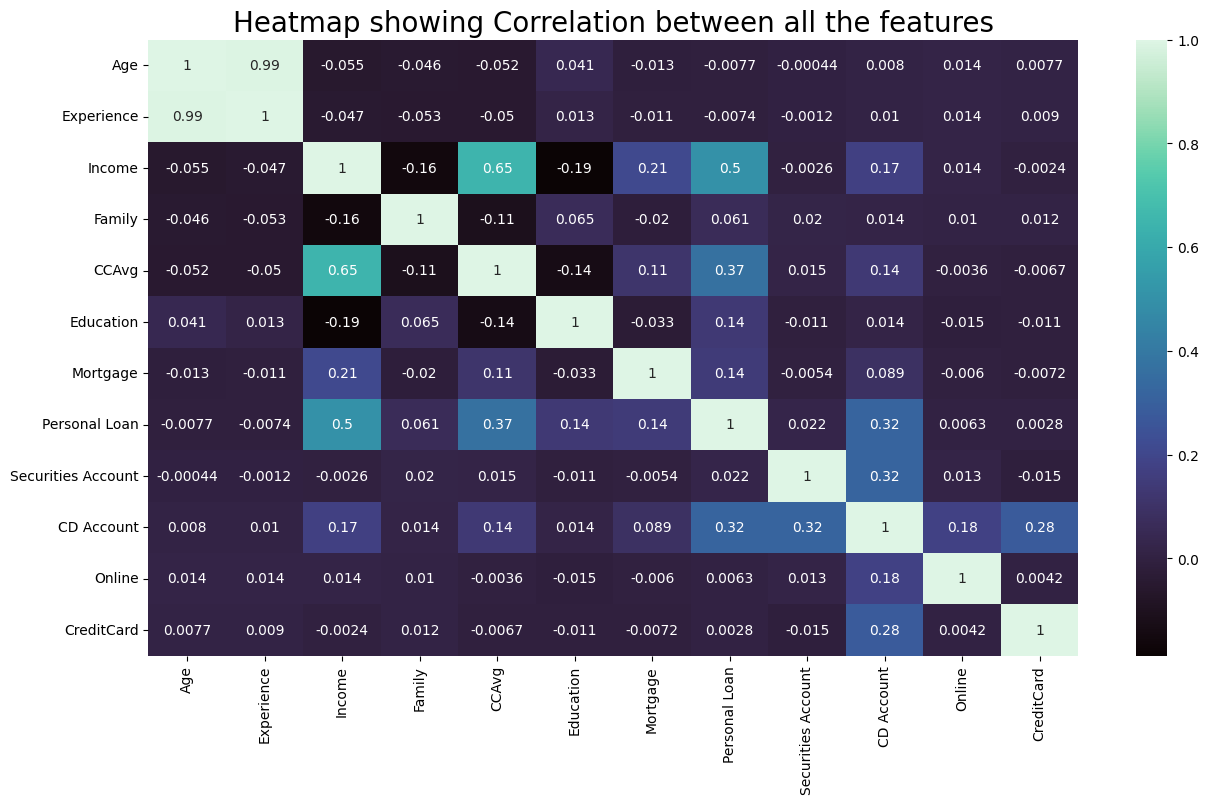

In [41]:
plt.figure(figsize=(15,8))
plt.title("Heatmap showing Correlation between all the features", fontsize=20)
sns.heatmap(df1.corr(),annot = True, cmap='mako')

In [42]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

SVM with Default hyperparameter i.e. C=10, kernel=rbf and gamma=auto



In [43]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
svc=SVC(C=10.0)
svc.fit(x_train, y_train)
y_pred=svc.predict(x_test)
print('Model accuracy with default hyperparameters : {0:0.3f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy with default hyperparameters : 0.742


SVM with rbf kernel and C=100

In [44]:
svc=SVC(C=100.0)
svc.fit(x_train, y_train)
y_pred=svc.predict(x_test)
print('Model accuracy with rbf kernel and C=100.0 : {0:0.3f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy with rbf kernel and C=100.0 : 0.720


SVM with linear kernel and C=10

In [45]:
linear_svc=SVC(kernel='linear', C=10.0).fit(x_train,y_train)
y_pred_test=linear_svc.predict(x_test)
print('Model accuracy score with linear kernel and C=10 : {0:0.3f}'. format(accuracy_score(y_test, y_pred_test)))

Model accuracy score with linear kernel and C=10 : 0.747


SVM with polynomial kernel and C=10

In [46]:
poly_svc=SVC(kernel='poly', C=10.0)
poly_svc.fit(x_train,y_train)
y_pred=poly_svc.predict(x_test)
print('Model accuracy score with polynomial kernel and C=10 : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score with polynomial kernel and C=10 : 0.7440


SVM with polynomial kernel and C=100

In [47]:
poly_svc=SVC(kernel='poly', C=10.0)
poly_svc.fit(x_train,y_train)
y_pred=poly_svc.predict(x_test)
print('Model accuracy score with polynomial kernel and C=10 : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

Model accuracy score with polynomial kernel and C=10 : 0.7440


Confusion matrix

In [48]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_test)
print('Confusion matrix\n\n', cm)
print('\nTrue Positives(TP) = ', cm[0,0])
print('\nTrue Negatives(TN) = ', cm[1,1])
print('\nFalse Positives(FP) = ', cm[0,1])
print('\nFalse Negatives(FN) = ', cm[1,0])

Confusion matrix

 [[696   8]
 [245  51]]

True Positives(TP) =  696

True Negatives(TN) =  51

False Positives(FP) =  8

False Negatives(FN) =  245


<Axes: >

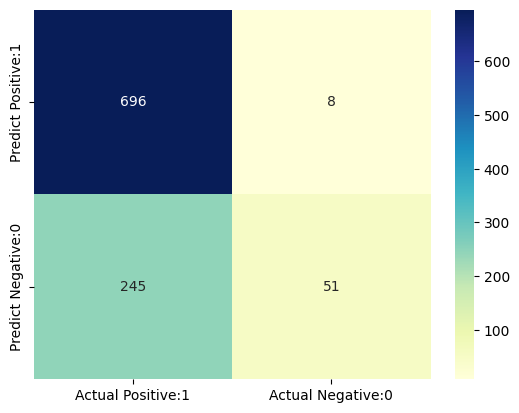

In [49]:
cm_matrix = pd.DataFrame(data=cm, columns=['Actual Positive:1', 'Actual Negative:0'],
                                 index=['Predict Positive:1', 'Predict Negative:0'])

sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='YlGnBu')

Classification Report

In [50]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.74      0.99      0.85       704
           1       0.86      0.17      0.29       296

    accuracy                           0.75      1000
   macro avg       0.80      0.58      0.57      1000
weighted avg       0.78      0.75      0.68      1000



Accuracy


In [51]:
TP = cm[0,0]
TN = cm[1,1]
FP = cm[0,1]
FN = cm[1,0]

Precision

In [52]:
precision = TP / float(TP + FP)
print('Precision : {0:0.4f}'.format(precision))

Precision : 0.9886


Recall

In [53]:
recall = TP / float(TP + FN)
print('Recall or Sensitivity : {0:0.4f}'.format(recall))

Recall or Sensitivity : 0.7396


Specificity

In [54]:
specificity = TN / (TN + FP)
print('Specificity : {0:0.4f}'.format(specificity))

Specificity : 0.8644
